THE GENERAL STEPS NEEDED FOR IMPLEMENTING THE MANUAL PIPELINE

In [11]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns


In [12]:
data = pd.read_csv("Titanic-Dataset.csv")

In [13]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

NUMBER OF NULL VALUES IN ENTIRE DATASET 

In [14]:
data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [23]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [24]:
data.drop(columns= ["PassengerId" , "Name" , "Ticket" , "Cabin"] , inplace = True)

In [25]:
data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [64]:
data.Sex.unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [22]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [16]:
data.shape

(891, 12)

In [17]:
data.Embarked.unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

<Axes: xlabel='Pclass', ylabel='Survived'>

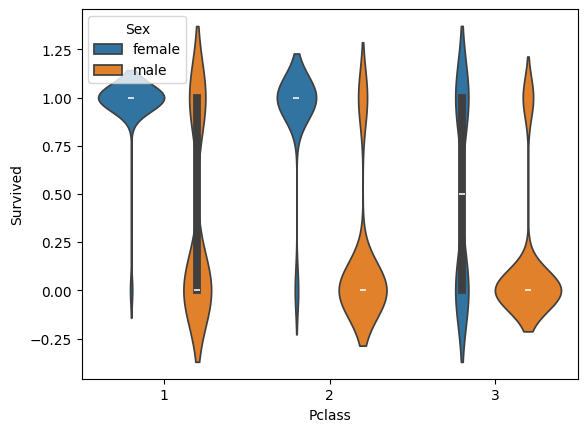

In [18]:
sns.violinplot(x = data.Pclass , y =  data.Survived , hue = data.Sex)

In [26]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

 

In [28]:
y = data.iloc[: , 0]
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [31]:
data.shape

(891, 8)

In [33]:
z = data.drop(data.iloc[ : , 0])
z.shape

(889, 8)

In [30]:
X = data.drop(data.iloc[ : , 0])
X

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
5,0,3,male,NaN,0,0,8.4583,Q
6,0,1,male,54.0,0,0,51.8625,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [34]:
X_train , X_test , y_train , y_test = train_test_split(data.drop(columns = ['Survived'])  , data.Survived , random_state = 42 , test_size = 0.2)

TypeError: 'Index' object is not callable

In [35]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,1,male,45.5,0,0,28.5000,S
733,2,male,23.0,0,0,13.0000,S
382,3,male,32.0,0,0,7.9250,S
704,3,male,26.0,1,0,7.8542,S
813,3,female,6.0,4,2,31.2750,S
...,...,...,...,...,...,...,...
106,3,female,21.0,0,0,7.6500,S
270,1,male,NaN,0,0,31.0000,S
860,3,male,41.0,2,0,14.1083,S
435,1,female,14.0,1,2,120.0000,S


#Applying Imputation

In [48]:
sI_age = SimpleImputer()
sI_embarked = SimpleImputer(strategy= "most_frequent")


sI_age_train = sI_age.fit_transform(X_train[['Age']])
sI_embark_train = sI_embarked.fit_transform(X_train[['Embarked']])

sI_age_test = sI_age.transform(X_test[['Age']])
sI_embark_test = sI_embarked.transform(X_test[['Embarked']])


In [39]:
sI_age_test

array([[29.49884615],
       [31.        ],
       [20.        ],
       [ 6.        ],
       [14.        ],
       [26.        ],
       [29.49884615],
       [16.        ],
       [16.        ],
       [19.        ],
       [37.        ],
       [44.        ],
       [29.49884615],
       [30.        ],
       [36.        ],
       [16.        ],
       [42.        ],
       [29.49884615],
       [27.        ],
       [47.        ],
       [24.        ],
       [34.        ],
       [19.        ],
       [20.        ],
       [29.49884615],
       [10.        ],
       [40.        ],
       [31.        ],
       [ 4.        ],
       [31.        ],
       [19.        ],
       [22.        ],
       [29.49884615],
       [29.49884615],
       [18.        ],
       [27.        ],
       [28.        ],
       [29.49884615],
       [30.        ],
       [29.49884615],
       [21.        ],
       [29.        ],
       [29.49884615],
       [29.49884615],
       [45.        ],
       [16

#MAKING ONE HOT ENCODER FOR SEX AND EMBARKED

In [40]:
ohe_sex = OneHotEncoder(sparse_output = False , handle_unknown= 'ignore')
ohe_embark = OneHotEncoder(sparse_output = False , handle_unknown= 'ignore')

ohe_sex_train  = ohe_sex.fit_transform(X_train[['Sex']])
ohe_embark_train = ohe_embark.fit_transform(X_train[['Embarked']])

ohe_sex_test = ohe_sex.transform(X_test[['Sex']])
ohe_embark_test = ohe_embark.transform(X_test[['Embarked']])

In [41]:
ohe_sex_test

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.

In [42]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,1,male,45.5,0,0,28.5000,S
733,2,male,23.0,0,0,13.0000,S
382,3,male,32.0,0,0,7.9250,S
704,3,male,26.0,1,0,7.8542,S
813,3,female,6.0,4,2,31.2750,S
...,...,...,...,...,...,...,...
106,3,female,21.0,0,0,7.6500,S
270,1,male,NaN,0,0,31.0000,S
860,3,male,41.0,2,0,14.1083,S
435,1,female,14.0,1,2,120.0000,S


In [45]:
X_train_rem

,Pclass,SibSp,Parch,Fare
331,1,0,0,28.5000
733,2,0,0,13.0000
382,3,0,0,7.9250
704,3,1,0,7.8542
813,3,4,2,31.2750
...,...,...,...,...
106,3,0,0,7.6500
270,1,0,0,31.0000
860,3,2,0,14.1083
435,1,1,2,120.0000


In [46]:
X_train_rem = X_train.drop(columns = ['Sex' , 'Age' , 'Embarked'])
X_test_rem = X_test.drop(columns = ['Sex' , 'Age' , 'Embarked'])


In [49]:
X_train_transformed = np.concatenate((X_train_rem, sI_age_train , ohe_sex_train , ohe_embark_train), axis = 1)
X_test_transformed = np.concatenate((X_test_rem, sI_age_test , ohe_sex_test , ohe_embark_test) ,axis =1) 

In [50]:
from sklearn.tree import DecisionTreeClassifier
dTC = DecisionTreeClassifier()

In [51]:
dTC.fit(X_train_transformed , y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [53]:
y_pred = dTC.predict(X_test_transformed)
y_pred

array([0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1])

In [54]:
from sklearn.metrics import accuracy_score
Accuracy = accuracy_score(y_test  , y_pred)
Accuracy

0.7932960893854749

In [56]:
import pickle

In [59]:
pickle.dump(ohe_sex , open('ohe_sex.pkl' , 'wb') )
pickle.dump(ohe_embark, open('ohe_embark.pkl' , 'wb'))
pickle.dump(dTC , open('dTC.pkl' , 'wb'))

In [63]:
X_train_transformed

array([[1., 0., 0., ..., 0., 1., 0.],
       [2., 0., 0., ..., 0., 1., 0.],
       [3., 0., 0., ..., 0., 1., 0.],
       ...,
       [3., 2., 0., ..., 0., 1., 0.],
       [1., 1., 2., ..., 0., 1., 0.],
       [1., 0., 1., ..., 0., 1., 0.]], shape=(712, 11))